# Exercise 3 – Word2Vec with Linear SVM and Random Forest

This notebook adapts the Word2Vec example to:
- Use gensim downloader API for word2vec-google-news-300
- Compare Linear SVM and Random Forest classifiers
- Display confusion matrices for both classifiers

In [1]:
# Install requirements
!pip install -q numpy pandas gensim nltk scikit-learn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
# Basic imports
import warnings
warnings.filterwarnings('ignore')
import os

# Pre-processing imports
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation

# Modeling imports
import numpy as np
import pandas as pd
import gensim.downloader as api
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/miriamplametshofer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/miriamplametshofer/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# Prepare the dataset
data_path = "../Data"
fil = 'sentiment_sentences.txt'

if not os.path.exists(os.path.join(data_path, fil)):
    # Combined the three files to make sentiment_sentences.txt
    filenames = ['amazon_cells_labelled.txt', 'imdb_labelled.txt', 'yelp_labelled.txt']
    
    with open(os.path.join(data_path, 'sentiment_sentences.txt'), 'w') as outfile:
        for fname in filenames:
            file_path = os.path.join(data_path, 'sentiment labelled sentences', fname)
            with open(file_path) as infile:
                outfile.write(infile.read())
    print("File created")
else:
    print("File already exists")

training_data_path = os.path.join(data_path, "sentiment_sentences.txt")

File already exists


In [4]:
# Load pre-trained Word2Vec model using gensim downloader API
print("Loading Word2Vec model using gensim downloader...")
print("This may take a few minutes on first run...")
w2v_model = api.load('word2vec-google-news-300')
print('Done loading Word2Vec')
print(f'Vocabulary size: {len(w2v_model)}')

Loading Word2Vec model using gensim downloader...
This may take a few minutes on first run...
Done loading Word2Vec
Vocabulary size: 3000000


In [5]:
# Read text data and labels
texts = []
cats = []

with open(training_data_path) as fh:
    for line in fh:
        text, sentiment = line.split("\t")
        texts.append(text)
        cats.append(sentiment.strip())

print(f"Loaded {len(texts)} texts and {len(cats)} labels")
print(f"Sample text: {texts[1]}")
print(f"Sample label: {cats[1]}")

Loaded 3000 texts and 3000 labels
Sample text: Good case, Excellent value.
Sample label: 1


In [6]:
# Preprocess the text
def preprocess_corpus(texts):
    mystopwords = set(stopwords.words("english"))
    
    def remove_stops_digits(tokens):
        # Lowercase, remove stopwords, digits and punctuation
        return [token.lower() for token in tokens 
                if token.lower() not in mystopwords 
                and not token.isdigit()
                and token not in punctuation]
    
    return [remove_stops_digits(word_tokenize(text)) for text in texts]

texts_processed = preprocess_corpus(texts)
print(f"Processed {len(texts_processed)} texts")
print(f"Sample processed text: {texts_processed[1]}")

Processed 3000 texts
Sample processed text: ['good', 'case', 'excellent', 'value']


In [7]:
# Create feature vectors by averaging word embeddings
def embedding_feats(list_of_lists, model):
    DIMENSION = 300
    zero_vector = np.zeros(DIMENSION)
    feats = []
    
    for tokens in list_of_lists:
        feat_for_this = np.zeros(DIMENSION)
        count_for_this = 0 + 1e-5  # to avoid divide-by-zero
        
        for token in tokens:
            if token in model:
                feat_for_this += model[token]
                count_for_this += 1
        
        if count_for_this != 0:
            feats.append(feat_for_this / count_for_this)
        else:
            feats.append(zero_vector)
    
    return np.array(feats)

train_vectors = embedding_feats(texts_processed, w2v_model)
print(f"Created {len(train_vectors)} feature vectors")
print(f"Feature vector shape: {train_vectors[0].shape}")

Created 3000 feature vectors
Feature vector shape: (300,)


In [8]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    train_vectors, cats, test_size=0.25, random_state=1234
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 2250
Test set size: 750


## Linear Support Vector Machine Classifier

In [9]:
# Train Linear SVM classifier
print("Training Linear SVM...")
svm_classifier = LinearSVC(random_state=1234, max_iter=2000)
svm_classifier.fit(X_train, y_train)

# Predict and evaluate
svm_preds = svm_classifier.predict(X_test)
svm_accuracy = svm_classifier.score(X_test, y_test)

print(f"\nLinear SVM Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report (Linear SVM):")
print(classification_report(y_test, svm_preds))

Training Linear SVM...

Linear SVM Accuracy: 0.7853

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       369
           1       0.79      0.79      0.79       381

    accuracy                           0.79       750
   macro avg       0.79      0.79      0.79       750
weighted avg       0.79      0.79      0.79       750



<Figure size 600x500 with 0 Axes>

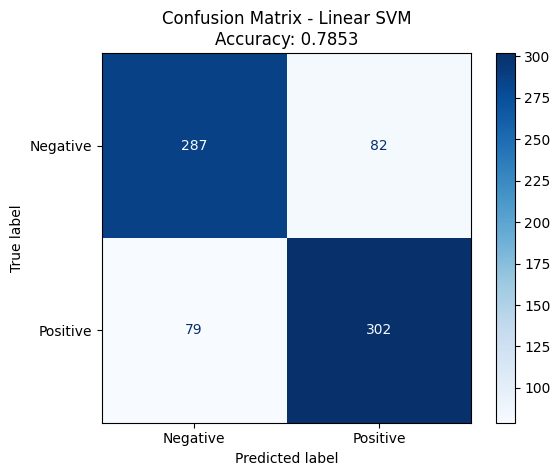

In [10]:
# Plot confusion matrix for Linear SVM
cm_svm = confusion_matrix(y_test, svm_preds)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['Negative', 'Positive']
)

plt.figure(figsize=(6, 5))
disp_svm.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - Linear SVM\nAccuracy: {svm_accuracy:.4f}")
plt.show()

## Random Forest Classifier

In [11]:
# Train Random Forest classifier
print("Training Random Forest...")
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=1234,
    n_jobs=-1
)
rf_classifier.fit(X_train, y_train)

# Predict and evaluate
rf_preds = rf_classifier.predict(X_test)
rf_accuracy = rf_classifier.score(X_test, y_test)

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_preds))

Training Random Forest...

Random Forest Accuracy: 0.7947

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       369
           1       0.81      0.78      0.79       381

    accuracy                           0.79       750
   macro avg       0.80      0.79      0.79       750
weighted avg       0.80      0.79      0.79       750



<Figure size 600x500 with 0 Axes>

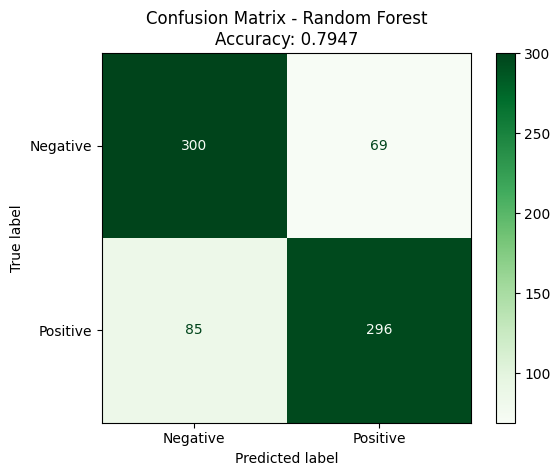

In [12]:
# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Negative', 'Positive']
)

plt.figure(figsize=(6, 5))
disp_rf.plot(cmap="Greens", values_format="d")
plt.title(f"Confusion Matrix - Random Forest\nAccuracy: {rf_accuracy:.4f}")
plt.show()

## Comparison of Results


COMPARISON SUMMARY
    Classifier  Accuracy
    Linear SVM  0.785333
 Random Forest  0.794667

✓ Random Forest performs better by 0.0093 (0.93%)


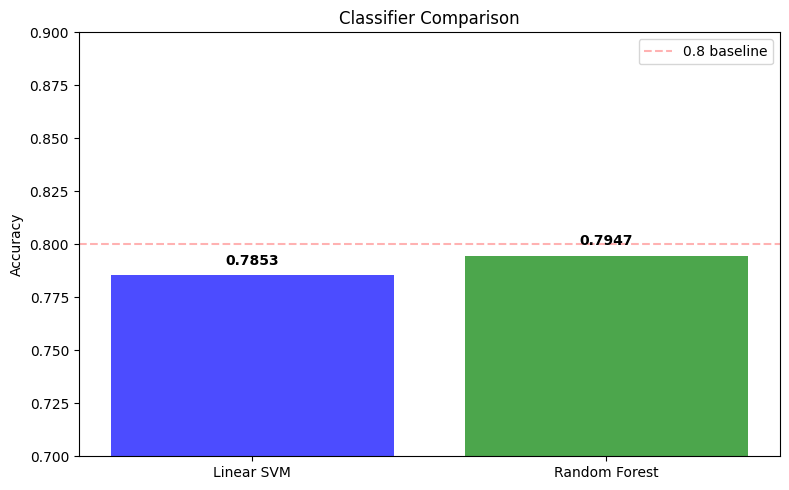

In [13]:
# Compare both classifiers
comparison = pd.DataFrame({
    'Classifier': ['Linear SVM', 'Random Forest'],
    'Accuracy': [svm_accuracy, rf_accuracy]
})

print("\n" + "="*50)
print("COMPARISON SUMMARY")
print("="*50)
print(comparison.to_string(index=False))
print("="*50)

if svm_accuracy > rf_accuracy:
    diff = svm_accuracy - rf_accuracy
    print(f"\n✓ Linear SVM performs better by {diff:.4f} ({diff*100:.2f}%)")
elif rf_accuracy > svm_accuracy:
    diff = rf_accuracy - svm_accuracy
    print(f"\n✓ Random Forest performs better by {diff:.4f} ({diff*100:.2f}%)")
else:
    print("\nBoth classifiers have equal accuracy!")

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison['Classifier'], comparison['Accuracy'], color=['blue', 'green'], alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Classifier Comparison')
plt.ylim([0.7, 0.9])
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.3, label='0.8 baseline')
for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()